# Text Classification

1) Setup path  
2) (Proof) Load dataset via `datasets.load_dataset`  
3) Load via `modules.data_loader.load_data` (single source of truth for pipeline)  
4) TF‑IDF (subset) → Save features  
5) Train/Eval Logistic Regression baseline → Pretty output  


In [1]:
%reload_ext autoreload
%autoreload 2

# Setup path
from pathlib import Path
import sys
# Import lib
import numpy as np
import pandas as pd
from pathlib import Path
import sys

def find_project_root(start=Path.cwd()):
    for p in [start] + list(start.parents):
        if (p / "modules").exists() and (p / "requirements.txt").exists():
            return p
    raise RuntimeError("Cannot find project root")

PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

from datasets import load_dataset
from modules.config import Config
from modules.data_loader import load_data
from modules.pipeline import build_features, run_evaluation
from modules.text_preprocess import TextCleaner

cfg = Config()


PROJECT_ROOT: C:\Users\ghuy2\Documents\BACH KHOA\HK_252\ML\MachineLearning_TextModule


## 3) Proof: load dataset directly from Hugging Face



In [2]:
ds = load_dataset(cfg.dataset_name)
print(ds)
print(ds["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


## 4) Pipeline load (via module)



In [3]:
train_texts, train_labels, test_texts, test_labels, info = load_data(cfg.dataset_name)

print(info)
print("Train:", len(train_texts), "Test:", len(test_texts))

DatasetInfo(name='ag_news', train_size=120000, test_size=7600, text_field='text', label_field='label', num_classes=4)
Train: 120000 Test: 7600


## 5) PREPROCESS 

In [4]:
## 5) PREPROCESSING + FEATURE EXTRACTION handled by pipeline
print(f"Running in mode: {cfg.mode.upper()}")
print(f"Preprocessing enabled: {cfg.use_preprocessing}")

# Pass raw texts to build_features; pipeline will slice & preprocess as needed
X_train, X_test, N_train, N_test = build_features(cfg, train_texts, test_texts)

print(f"Train samples used: {N_train}")
print(f"Test  samples used: {N_test}")

Running in mode: DEMO
Preprocessing enabled: True
SBERT embeddings saved:
C:\Users\ghuy2\Documents\BACH KHOA\HK_252\ML\MachineLearning_TextModule\modules\features\bert\bert_train.npy C:\Users\ghuy2\Documents\BACH KHOA\HK_252\ML\MachineLearning_TextModule\modules\features\bert\bert_test.npy
Train samples used: 5000
Test  samples used: 2000


## 6) FEATURE EXTRACTION

In [5]:
X_train, X_test, _, _ = build_features(cfg, train_texts, test_texts)

print(X_train.shape, X_test.shape)

SBERT embeddings saved:
C:\Users\ghuy2\Documents\BACH KHOA\HK_252\ML\MachineLearning_TextModule\modules\features\bert\bert_train.npy C:\Users\ghuy2\Documents\BACH KHOA\HK_252\ML\MachineLearning_TextModule\modules\features\bert\bert_test.npy
(2000, 384) (500, 384)


## 7) Train/Evaluation 

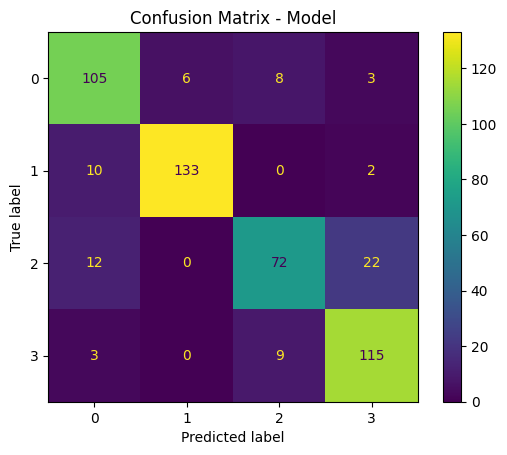

,0,1
0,"EvalResult(accuracy=0.85, precision_weighted=0...",accuracy precision_weighted recall_weight...


In [6]:
results = run_evaluation(X_train, train_labels, X_test, test_labels,cfg)
pd.DataFrame([results])